# Identify relative bakery under-provision across London MSOAs

Under-provision is examined separately under all three bakery definitions:
- core bakeries only
- core bakeries and bakery cafés
- all provision including supermarkets

The three definitions are subsequently compared using equally weighted rankings.

In [1]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

DATA_DATE = "2026-07-23"
EXPECTED_MSOAS = 1002

SPATIAL_PROCESSED_FOLDER = Path("../data/spatial/processed")
MODEL_OUTPUT_FOLDER = Path("../outputs/models")

TABLE_FOLDER = Path("../outputs/tables")
TABLE_FOLDER.mkdir(parents=True, exist_ok=True)

FIGURE_FOLDER = Path("../outputs/figures")
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

MODEL_DATA_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_income_model_predictions_{DATA_DATE}.csv")
MODEL_COMPARISON_PATH = (TABLE_FOLDER / f"income_model_comparison_{DATA_DATE}.csv")
MSOA_PATH = (SPATIAL_PROCESSED_FOLDER / "london_msoa_2021.gpkg")

print(f"Model data found: {MODEL_DATA_PATH.exists()}")
print(f"Model comparison found: {MODEL_COMPARISON_PATH.exists()}")
print(f"MSOA boundaries found: {MSOA_PATH.exists()}")

Model data found: True
Model comparison found: True
MSOA boundaries found: True


## Load final model results and MSOA boundaries

In [2]:
model_data = pd.read_csv(MODEL_DATA_PATH,
                         dtype={"msoa_code": "string"},
                         low_memory=False)

model_comparison = pd.read_csv(MODEL_COMPARISON_PATH)
msoa_boundaries = gpd.read_file(MSOA_PATH)

msoa_boundaries["msoa_code"] = (msoa_boundaries["msoa_code"]
                                .astype("string")
                                .str.strip())

print(f"Model rows: {len(model_data)}")
print(f"MSOA boundary rows: {len(msoa_boundaries)}")

display(model_comparison[["Definition", "Income model AIC", "Income model alpha"]].round(3))

Model rows: 1002
MSOA boundary rows: 1002


,Definition,Income model AIC,Income model alpha
0,Core only,2548.875,1.080
1,Core and café,4127.116,1.088
2,All provision included,5205.474,0.662


In [3]:
required_columns = ["msoa_code",
                    "msoa_name",
                    "borough_code",
                    "borough_name",
                    "area_km2",
                    "population",
                    "transport_nodes",
                    "income_bhc",
                    "core_bakery_count",
                    "core_and_cafe_count",
                    "bakery_count",
                    "income_expected_core_bakery_count",
                    "income_expected_core_and_cafe_count",
                    "income_expected_bakery_count"]

missing_columns = [column for column in required_columns
                   if column not in model_data.columns]

if missing_columns:
    raise KeyError(f"Missing model columns: {missing_columns}")

expected_columns = ["income_expected_core_bakery_count",
                    "income_expected_core_and_cafe_count",
                    "income_expected_bakery_count"]

print(f"Expected MSOAs: {EXPECTED_MSOAS}")
print(f"Model rows: {len(model_data)}")
print(f"Duplicate model MSOAs: {model_data['msoa_code'].duplicated().sum()}")
print(f"Missing expected values: {model_data[expected_columns].isna().sum().sum()}")
print(f"Duplicate boundary MSOAs: {msoa_boundaries['msoa_code'].duplicated().sum()}")
print(f"Missing geometries: {msoa_boundaries['geometry'].isna().sum()}")

Expected MSOAs: 1002
Model rows: 1002
Duplicate model MSOAs: 0
Missing expected values: 0
Duplicate boundary MSOAs: 0
Missing geometries: 0


## Calculate relative under-provision

Raw shortfall is calculated as the model-expected establishment count minus the observed count.

In [4]:
definition_settings = {"Core only": {"prefix": "core",
                                     "observed": "core_bakery_count",
                                     "expected": "income_expected_core_bakery_count"},
                       "Core and café": {"prefix": "core_cafe",
                                         "observed": "core_and_cafe_count",
                                         "expected": "income_expected_core_and_cafe_count"},
                       "All provision included": {"prefix": "all",
                                                  "observed": "bakery_count",
                                                  "expected": "income_expected_bakery_count"}}

alpha_lookup = (model_comparison
                .set_index("Definition")["Income model alpha"]
                .to_dict())

analysis_data = model_data.copy()

for definition, settings in definition_settings.items():
    prefix = settings["prefix"]
    observed = analysis_data[settings["observed"]]
    expected = analysis_data[settings["expected"]]
    alpha = alpha_lookup[definition]

    variance = expected + alpha * expected ** 2

    analysis_data[f"{prefix}_raw_shortfall"] = (expected - observed)
    analysis_data[f"{prefix}_standardised_shortfall"] = ((expected - observed) / np.sqrt(variance))
    analysis_data[f"{prefix}_underprovision_percentile"] = (analysis_data[f"{prefix}_standardised_shortfall"]
                                                            .rank(method="average", pct=True) * 100)
    analysis_data[f"{prefix}_underprovision_rank"] = (analysis_data[f"{prefix}_standardised_shortfall"]
                                                      .rank(method="min", ascending=False)
                                                      .astype(int))
    analysis_data[f"{prefix}_top_decile"] = (analysis_data[f"{prefix}_underprovision_percentile"] >= 90)

print("Under-provision scores calculated for all three definitions.")

Under-provision scores calculated for all three definitions.


In [5]:
score_summary_rows = []

for definition, settings in definition_settings.items():
    prefix = settings["prefix"]
    observed = analysis_data[settings["observed"]]
    expected = analysis_data[settings["expected"]]
    raw_shortfall = analysis_data[f"{prefix}_raw_shortfall"]
    standardised = analysis_data[f"{prefix}_standardised_shortfall"]

    score_summary_rows.append({"Definition": definition,
                               "Observed establishments": observed.sum(),
                               "Expected establishments": expected.sum(),
                               "MSOAs below expectation": (raw_shortfall > 0).sum(),
                               "Median raw shortfall": raw_shortfall.median(),
                               "Highest standardised shortfall": standardised.max()})

score_summary = pd.DataFrame(score_summary_rows)

display(score_summary.round({"Expected establishments": 1,
                             "Median raw shortfall": 2,
                             "Highest standardised shortfall": 2}))

,Definition,Observed establishments,Expected establishments,MSOAs below expectation,Median raw shortfall,Highest standardised shortfall
0,Core only,925,907.0,625,0.46,0.81
1,Core and café,2928,2800.9,652,0.76,0.90
2,All provision included,5178,5079.5,624,1.00,1.14


## Highest-ranked under-provided MSOAs

MSOAs are ranked separately under each bakery definition using their standardised shortfall.

In [6]:
top_area_tables = []

for definition, settings in definition_settings.items():
    prefix = settings["prefix"]

    top_table = (analysis_data
                 .sort_values(f"{prefix}_standardised_shortfall", ascending=False)
                 .head(20)[["msoa_code",
                            "msoa_name",
                            "borough_name",
                            settings["observed"],
                            settings["expected"],
                            f"{prefix}_raw_shortfall",
                            f"{prefix}_standardised_shortfall",
                            f"{prefix}_underprovision_rank"]].copy())

    top_table.insert(0, "Definition", definition)

    top_table = top_table.rename(columns={settings["observed"]: "Observed count",
                                          settings["expected"]: "Expected count",
                                          f"{prefix}_raw_shortfall": "Raw shortfall",
                                          f"{prefix}_standardised_shortfall": "Standardised shortfall",
                                          f"{prefix}_underprovision_rank": "Rank"})

    top_area_tables.append(top_table)

    print(f"\n{definition}")
    display(top_table.drop(columns="Definition").round({"Expected count": 2,
                                                        "Raw shortfall": 2,
                                                        "Standardised shortfall": 2}))

top_areas_by_definition = pd.concat(top_area_tables, ignore_index=True)


Core only


,msoa_code,msoa_name,borough_name,Observed count,Expected count,Raw shortfall,Standardised shortfall,Rank
841,E02000890,Tower Hamlets 027,Tower Hamlets,0,2.33,2.33,0.81,1
939,E02006789,Bromley 042,Bromley,0,2.31,2.31,0.81,2
999,E02007113,Tower Hamlets 035,Tower Hamlets,0,2.28,2.28,0.81,3
963,E02006941,Southwark 035,Southwark,0,2.22,2.22,0.81,4
222,E02000234,Croydon 041,Croydon,0,2.21,2.21,0.81,5
126,E02000132,Bromley 006,Bromley,0,2.10,2.10,0.80,6
739,E02000785,Richmond upon Thames 002,Richmond upon Thames,0,2.04,2.04,0.80,7
155,E02000162,Bromley 036,Bromley,0,2.02,2.02,0.80,8
215,E02000227,Croydon 034,Croydon,0,1.86,1.86,0.79,9
28,E02000030,Barnet 007,Barnet,0,1.73,1.73,0.78,10



Core and café


,msoa_code,msoa_name,borough_name,Observed count,Expected count,Raw shortfall,Standardised shortfall,Rank
222,E02000234,Croydon 041,Croydon,0,7.14,7.14,0.90,1
939,E02006789,Bromley 042,Bromley,0,6.11,6.11,0.89,2
140,E02000147,Bromley 021,Bromley,0,5.78,5.78,0.89,3
766,E02000814,Southwark 008,Southwark,0,5.77,5.77,0.89,4
215,E02000227,Croydon 034,Croydon,0,5.46,5.46,0.89,5
28,E02000030,Barnet 007,Barnet,0,5.16,5.16,0.88,6
224,E02000236,Croydon 043,Croydon,0,4.97,4.97,0.88,7
752,E02000798,Richmond upon Thames 015,Richmond upon Thames,0,4.95,4.95,0.88,8
219,E02000231,Croydon 038,Croydon,0,4.92,4.92,0.88,9
208,E02000219,Croydon 026,Croydon,0,4.91,4.91,0.88,10



All provision included


,msoa_code,msoa_name,borough_name,Observed count,Expected count,Raw shortfall,Standardised shortfall,Rank
766,E02000814,Southwark 008,Southwark,0,9.48,9.48,1.14,1
140,E02000147,Bromley 021,Bromley,0,8.78,8.78,1.14,2
219,E02000231,Croydon 038,Croydon,0,7.91,7.91,1.13,3
80,E02000084,Bexley 020,Bexley,0,7.91,7.91,1.13,4
735,E02000781,Redbridge 031,Redbridge,0,7.47,7.47,1.12,5
844,E02000895,Waltham Forest 001,Waltham Forest,0,6.69,6.69,1.11,6
243,E02000255,Ealing 018,Ealing,0,6.64,6.64,1.11,7
223,E02000235,Croydon 042,Croydon,0,6.61,6.61,1.11,8
607,E02000640,Lambeth 023,Lambeth,0,6.51,6.51,1.11,9
500,E02000532,Hounslow 007,Hounslow,0,6.40,6.40,1.11,10


## Map relative under-provision

The standardised shortfall is mapped using Red MSOAs as those with under-provision and Blue as those with more provision than expected (across the three bakery definitions).

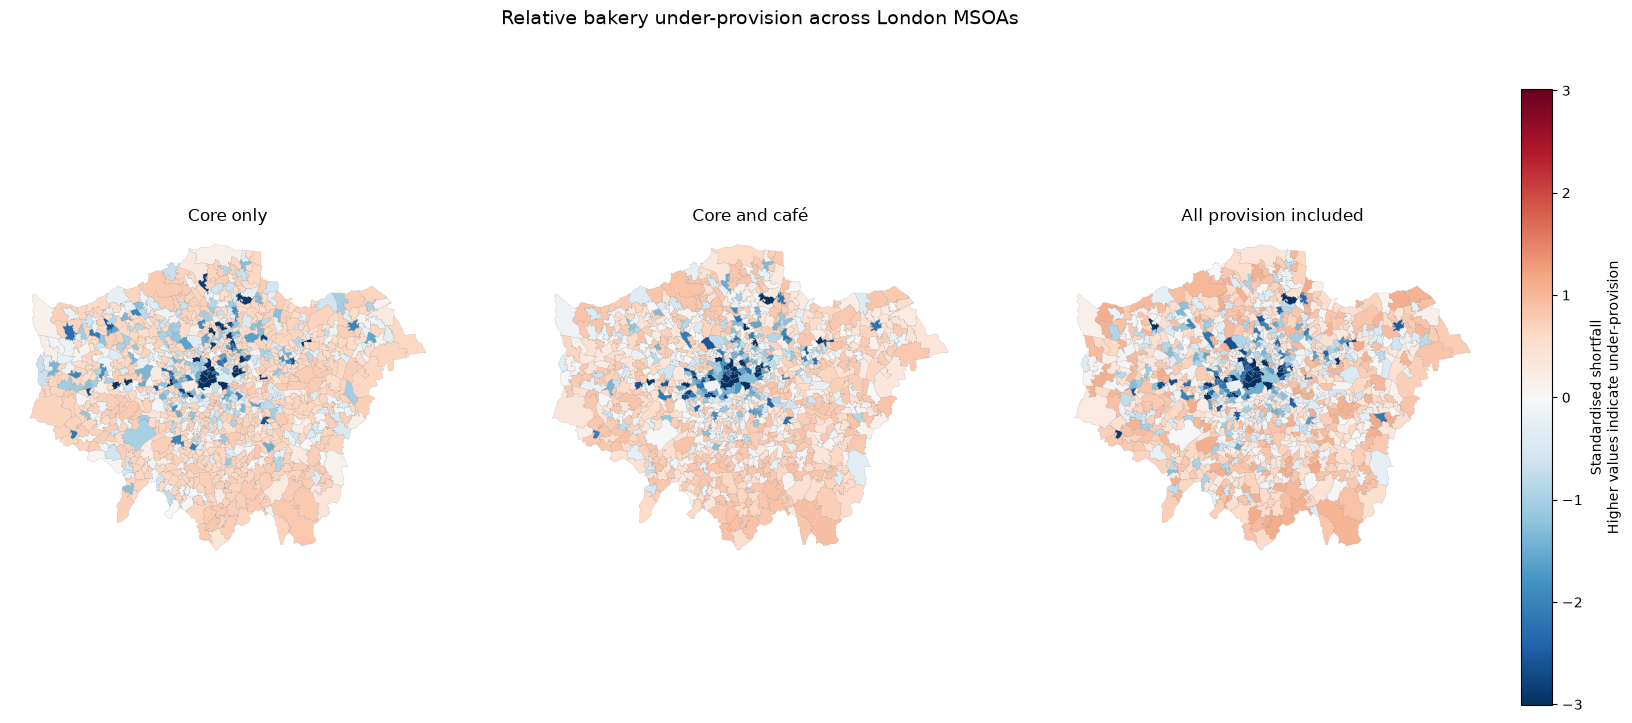

Saved to: ..\outputs\figures\msoa_underprovision_by_definition_2026-07-23.png


In [7]:
from matplotlib.colors import TwoSlopeNorm

score_columns = ["core_standardised_shortfall",
                 "core_cafe_standardised_shortfall",
                 "all_standardised_shortfall"]

map_data = (msoa_boundaries[["msoa_code", "geometry"]]
            .merge(analysis_data[["msoa_code"] + score_columns], 
                   on="msoa_code",
                   how="left",
                   validate="one_to_one"))

all_scores = np.concatenate([map_data[column].dropna().to_numpy()
                             for column in score_columns])

colour_limit = np.quantile(np.abs(all_scores), 0.98)
colour_limit = max(colour_limit, 1)

colour_norm = TwoSlopeNorm(vmin=-colour_limit,
                           vcenter=0,
                           vmax=colour_limit)

map_definitions = [("Core only", "core_standardised_shortfall"),
                   ("Core and café", "core_cafe_standardised_shortfall"),
                   ("All provision included", "all_standardised_shortfall")]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for axis, (definition, column) in zip(axes, map_definitions):
    map_data.plot(column=column,
                  cmap="RdBu_r",
                  norm=colour_norm,
                  linewidth=0.1,
                  edgecolor="grey",
                  ax=axis)

    axis.set_title(definition)
    axis.axis("off")

colour_scale = plt.cm.ScalarMappable(norm=colour_norm, cmap="RdBu_r")

colour_bar = fig.colorbar(colour_scale,
                          ax=axes,
                          fraction=0.025,
                          pad=0.02)

colour_bar.set_label("Standardised shortfall\nHigher values indicate under-provision")

fig.suptitle("Relative bakery under-provision across London MSOAs", fontsize=14)

UNDERPROVISION_MAP_PATH = (FIGURE_FOLDER / f"msoa_underprovision_by_definition_{DATA_DATE}.png")
plt.savefig(UNDERPROVISION_MAP_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {UNDERPROVISION_MAP_PATH}")

## Compare definitions and calculate a consensus ranking

Each MSOA's standardised under-provision score is converted into a percentile within its respective definition and averaged for a consensus ranking.

It summarises how consistently an MSOA appears under-provided across the three existing definitions.

In [8]:
percentile_columns = ["core_underprovision_percentile",
                      "core_cafe_underprovision_percentile",
                      "all_underprovision_percentile"]

top_decile_columns = ["core_top_decile",
                      "core_cafe_top_decile",
                      "all_top_decile"]

analysis_data["consensus_underprovision_score"] = (analysis_data[percentile_columns]
                                                   .mean(axis=1))

analysis_data["consensus_underprovision_rank"] = (analysis_data["consensus_underprovision_score"]
                                                  .rank(method="min", ascending=False)
                                                  .astype(int))

analysis_data["definitions_in_top_decile"] = (analysis_data[top_decile_columns]
                                              .sum(axis=1))

definition_labels = list(definition_settings.keys())

pairwise_overlap = pd.DataFrame(index=definition_labels,
                                columns=definition_labels,
                                dtype=int)

for first_definition, first_settings in definition_settings.items():
    for second_definition, second_settings in definition_settings.items():

        first_flag = f"{first_settings['prefix']}_top_decile"
        second_flag = f"{second_settings['prefix']}_top_decile"

        pairwise_overlap.loc[first_definition, second_definition
                             ] = (analysis_data[first_flag] &
                                  analysis_data[second_flag]).sum()

print("Number of shared top-decile MSOAs")
display(pairwise_overlap.astype(int))

consensus_top = (analysis_data
                 .sort_values("consensus_underprovision_score", ascending=False)
                 .head(20)[["msoa_code",
                            "msoa_name",
                            "borough_name",
                            "core_standardised_shortfall",
                            "core_cafe_standardised_shortfall",
                            "all_standardised_shortfall",
                            "definitions_in_top_decile",
                            "consensus_underprovision_score",
                            "consensus_underprovision_rank"]].copy())

consensus_top = consensus_top.rename(columns={"core_standardised_shortfall": "Core score",
                                              "core_cafe_standardised_shortfall": "Core and café score",
                                              "all_standardised_shortfall": "All-provision score",
                                              "definitions_in_top_decile": "Definitions in top decile",
                                              "consensus_underprovision_score": "Consensus score",
                                              "consensus_underprovision_rank": "Consensus rank"})

print("\nHighest consensus-ranked MSOAs")

display(consensus_top.round({"Core score": 2,
                             "Core and café score": 2,
                             "All-provision score": 2,
                             "Consensus score": 1}))

Number of shared top-decile MSOAs


,Core only,Core and café,All provision included
Core only,101,35,19
Core and café,35,101,38
All provision included,19,38,101



Highest consensus-ranked MSOAs


,msoa_code,msoa_name,borough_name,Core score,Core and café score,All-provision score,Definitions in top decile,Consensus score,Consensus rank
140,E02000147,Bromley 021,Bromley,0.77,0.89,1.14,3,99.5,1
219,E02000231,Croydon 038,Croydon,0.76,0.88,1.13,3,98.8,2
766,E02000814,Southwark 008,Southwark,0.75,0.89,1.14,3,98.6,3
844,E02000895,Waltham Forest 001,Waltham Forest,0.76,0.86,1.11,3,98.1,4
215,E02000227,Croydon 034,Croydon,0.79,0.89,1.04,3,98.0,5
80,E02000084,Bexley 020,Bexley,0.74,0.86,1.13,3,97.9,6
939,E02006789,Bromley 042,Bromley,0.81,0.89,1.02,3,97.6,7
223,E02000235,Croydon 042,Croydon,0.74,0.87,1.11,3,97.5,8
28,E02000030,Barnet 007,Barnet,0.78,0.88,1.01,3,97.0,9
653,E02000690,Merton 002,Merton,0.72,0.87,1.09,3,96.4,10


Black boundaries show the 20 highest-ranked MSOAs.


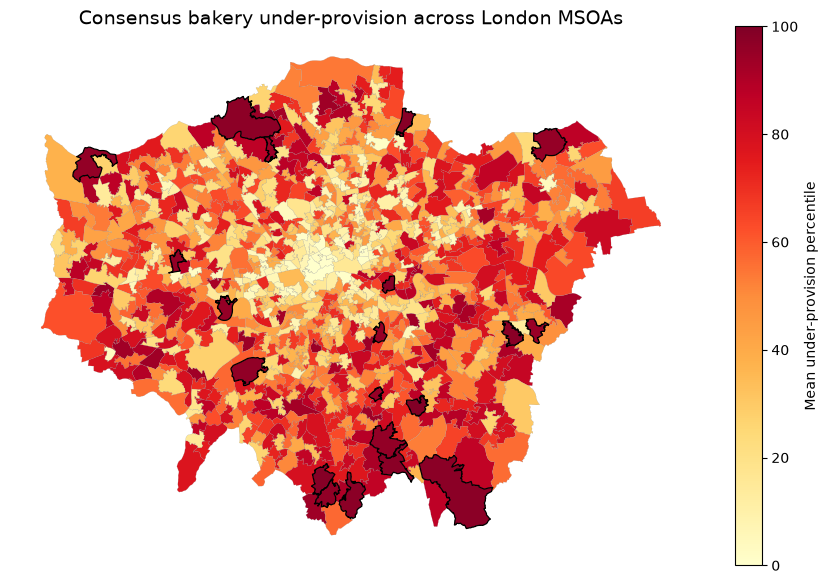

Saved to: ..\outputs\figures\msoa_underprovision_consensus_2026-07-23.png


In [10]:
consensus_map = (msoa_boundaries[["msoa_code", "geometry"]]
                 .merge(analysis_data[["msoa_code",
                                       "consensus_underprovision_score",
                                       "consensus_underprovision_rank"]],
                                       on="msoa_code",
                                       how="left", 
                                       validate="one_to_one"))

highest_ranked = consensus_map[consensus_map["consensus_underprovision_rank"] <= 20]

fig, axis = plt.subplots(figsize=(11, 10))

consensus_map.plot(column="consensus_underprovision_score",
                   cmap="YlOrRd",
                   vmin=0,
                   vmax=100,
                   linewidth=0.1,
                   edgecolor="grey",
                   legend=True,
                   legend_kwds={"label": "Mean under-provision percentile",
                                "shrink": 0.7},
                   ax=axis)

highest_ranked.boundary.plot(color="black", linewidth=0.9, ax=axis)

axis.set_title("Consensus bakery under-provision across London MSOAs", fontsize=14)

axis.axis("off")

CONSENSUS_MAP_PATH = (FIGURE_FOLDER / f"msoa_underprovision_consensus_{DATA_DATE}.png")
plt.savefig(CONSENSUS_MAP_PATH, dpi=300, bbox_inches="tight")

print(f"Black boundaries show the 20 highest-ranked MSOAs.")
plt.show()

print(f"Saved to: {CONSENSUS_MAP_PATH}")

## Save final under-provision results

The complete MSOA-level results, definition-specific top rankings and consensus ranking are saved for use in the dissertation results and mapping sections.

In [11]:
result_columns = ["msoa_code",
                  "msoa_name",
                  "borough_code",
                  "borough_name",
                  "area_km2",
                  "population",
                  "transport_nodes",
                  "income_bhc",
                  "core_bakery_count",
                  "core_and_cafe_count",
                  "bakery_count",
                  "income_expected_core_bakery_count",
                  "income_expected_core_and_cafe_count",
                  "income_expected_bakery_count",
                  "core_raw_shortfall",
                  "core_standardised_shortfall",
                  "core_underprovision_percentile",
                  "core_underprovision_rank",
                  "core_top_decile",
                  "core_cafe_raw_shortfall",
                  "core_cafe_standardised_shortfall",
                  "core_cafe_underprovision_percentile",
                  "core_cafe_underprovision_rank",
                  "core_cafe_top_decile",
                  "all_raw_shortfall",
                  "all_standardised_shortfall",
                  "all_underprovision_percentile",
                  "all_underprovision_rank",
                  "all_top_decile",
                  "definitions_in_top_decile",
                  "consensus_underprovision_score",
                  "consensus_underprovision_rank"]

underprovision_results = analysis_data[result_columns].copy()

UNDERPROVISION_RESULTS_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_underprovision_{DATA_DATE}.csv")
TOP_AREAS_PATH = (TABLE_FOLDER / f"top_underprovided_msoas_by_definition_{DATA_DATE}.csv")
CONSENSUS_TABLE_PATH = (TABLE_FOLDER / f"top_consensus_underprovided_msoas_{DATA_DATE}.csv")
OVERLAP_TABLE_PATH = (TABLE_FOLDER / f"underprovision_definition_overlap_{DATA_DATE}.csv")

underprovision_results.to_csv(UNDERPROVISION_RESULTS_PATH, index=False, encoding="utf-8-sig")
top_areas_by_definition.to_csv(TOP_AREAS_PATH, index=False, encoding="utf-8-sig")
consensus_top.to_csv(CONSENSUS_TABLE_PATH, index=False, encoding="utf-8-sig")
pairwise_overlap.to_csv(OVERLAP_TABLE_PATH, encoding="utf-8-sig")

print(f"Complete results saved to: {UNDERPROVISION_RESULTS_PATH}")
print(f"Definition rankings saved to: {TOP_AREAS_PATH}")
print(f"Consensus ranking saved to: {CONSENSUS_TABLE_PATH}")
print(f"Definition overlap saved to: {OVERLAP_TABLE_PATH}")

Complete results saved to: ..\outputs\models\london_msoa_bakery_underprovision_2026-07-23.csv
Definition rankings saved to: ..\outputs\tables\top_underprovided_msoas_by_definition_2026-07-23.csv
Consensus ranking saved to: ..\outputs\tables\top_consensus_underprovided_msoas_2026-07-23.csv
Definition overlap saved to: ..\outputs\tables\underprovision_definition_overlap_2026-07-23.csv
